In [1]:
import os

# Set the environment variable to avoid printing the error message
os.environ["EQX_ON_ERROR"] = "nan"

import numpy as np
import jax
import jax.numpy as jnp
import healpy as hp
from opt_einsum import contract

import matplotlib.pyplot as plt

from fgbuster import get_observation

import megabuster

jax.config.update("jax_enable_x64", True)


/shared_home/mag/MEGATOP/megatop_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Setting paths

In [3]:
path_MSS = '/cephfs/soukdata/user_data/jost/MEGATOP/Obsmat/OBSMAT_TO_SOUK/MSS2/'

path_nhits = path_MSS+f"sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits"
# The nhits is used to build the analysis mask (here without inhomogeneities), which must be compatible with the observation matrices 

path_N = '/shared_home/mag/MEGATOP/pixel_noisecov_preprocessed.npy'

# Preparing paths

# path_scratch = '/pscratch/sd/m/mag/fast_MSS2_obsmat/'
# path_precomputations = path_scratch

# # Prepare the paths of observation matrices 

# path_save_obsmat_file = "sobs_RC1.r01_SAT{}_mission_f{:03d}_4way_{}_sky_obsmat_healpix_"


# all_incomplete_path_save_obsmat_file = [path_save_obsmat_file.format(4, freq, 'coadd') for freq in [30, 40]]
# all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(1, freq, 'coadd') for freq in [90, 150]]
# all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(3, freq, 'coadd') for freq in [230, 290]]

# all_path_save_obsmat_file = [path_scratch + path for path in all_incomplete_path_save_obsmat_file]

# Generating input CMB and input mask

Setting up the parameters of the problem

In [4]:
nside = 128
npix = 12*nside**2
nstokes = 2

frequencies = np.array([27, 39, 93, 145, 225, 280])

n_freq = len(frequencies)

instrument = megabuster.helper.get_instrument('SO_SAT')


Generating the input map with fgbuster

In [5]:
np.random.seed(42)
input_foregrounds_maps = get_observation(instrument, 'd0s0', nside=nside, noise=False)

np.random.seed(42)
input_cmb = get_observation(instrument, 'c1', nside=nside, noise=False)

input_freq_maps = input_cmb + input_foregrounds_maps

np.float64(0.0572967529296875)

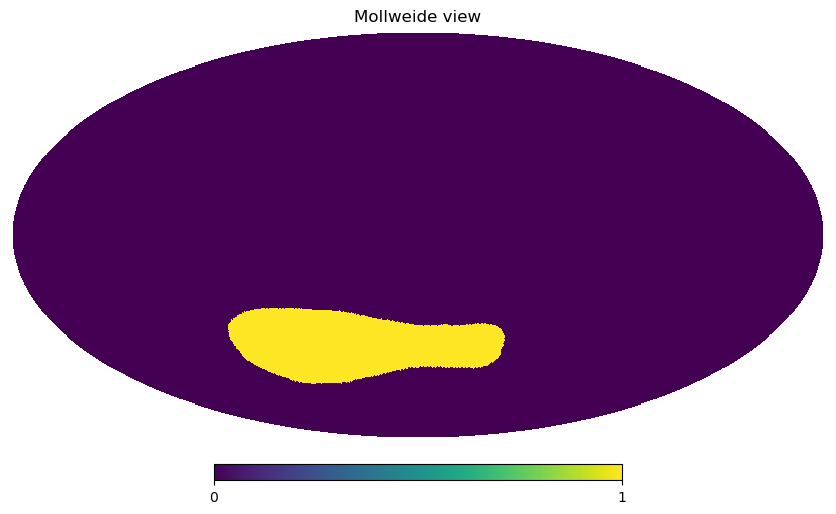

In [6]:
def make_mask(nhits_path, zero_threshold, nside):
    nhits_map = hp.read_map(nhits_path)
    nhits_smoothed = hp.smoothing(
        hp.ud_grade(nhits_map, nside, power=-2, dtype=np.float64),
        fwhm=np.pi/180)
    nhits_smoothed[nhits_smoothed < 0] = 0
    nhits_smoothed /= np.amax(nhits_smoothed)
    binary_mask = np.zeros_like(nhits_smoothed)
    binary_mask[nhits_smoothed > zero_threshold] = 1
    fsky = np.sum(binary_mask) / len(binary_mask)

    return binary_mask, fsky

nside_out = 128  # Output nside for the mask

zero_threshold = 0.45
mask_B, fsky = make_mask(path_nhits, zero_threshold, nside=nside_out)

theta, phi = hp.pix2ang(nside=nside_out, ipix=np.arange(mask_B.size), lonlat=True)

mask_south = np.zeros_like(mask_B)

mask_south[theta < 115] = 1
mask_south[theta > 280] = 1
mask_south[phi < -35] = 1
mask_south[phi > -15] = 0


mask_south[theta < 115] = 1
mask_south[theta > 280] = 1
mask_south[phi < -35] = 1
mask_south[phi > -15] = 0



mask_B_ring = mask_B * mask_south
mask_B_nest = hp.reorder(mask_B_ring, r2n=True)

mask_indices = mask_B_nest != 0
n_pix = int(mask_B_nest.sum())

hp.mollview(mask_B_nest, nest=True)
f_sky = mask_B_nest.sum() / mask_B_nest.size
f_sky

# Preparing path and loading obsmat

In [7]:
# Preparing the inverse noise covariance matrix --------------------------------
print("Loading the inverse noise covariance matrix from", path_N, flush=True)
def load_N_matrix(path_N, nside):
    N_matrix = np.load(path_N)
    if N_matrix.ndim != 2:
        output = []
        for i in range(N_matrix.shape[0]):
            output.append(hp.ud_grade(N_matrix[i], nside_out=nside, power=2))
        N_matrix = np.array(output)
    return N_matrix

N_matrix = load_N_matrix(path_N, nside)

Loading the inverse noise covariance matrix from /shared_home/mag/MEGATOP/pixel_noisecov_preprocessed.npy


Here the full observation matrices are loaded to filter the input data

In [8]:
noisecov_QU_masked = N_matrix[:,1:,:] * mask_B_ring
inverse_noisecov_QU_masked = np.zeros_like(noisecov_QU_masked)
inverse_noisecov_QU_masked[noisecov_QU_masked != 0] = 1./noisecov_QU_masked[noisecov_QU_masked != 0]

inverse_noisecov_QU_masked_nested = np.zeros_like(inverse_noisecov_QU_masked)
for i in range(n_freq):
    inverse_noisecov_QU_masked_nested[i,...] = hp.reorder(inverse_noisecov_QU_masked[i], r2n=True)

inverse_noisecov_QU_masked_nested = jnp.array(inverse_noisecov_QU_masked_nested)

In [9]:
%%time
res_sanity = megabuster.compsep.perform_compsep( 
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=input_freq_maps[:,1:,:] * mask_B_ring,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        use_preconditioner_diag=True,
        use_preconditioner_pinv=False,
        matrix_precond=None,
        central_freq_op=None,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-5},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-6},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
[WARNING] optx.TqdmProgressMeter not found. Progress meter disabled.
Using diagonal preconditioner
Using diagonal preconditioner
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
Number of iterations in CG: 2
{'beta_dust': Array(1.54, dtype=float64), 'beta_pl': Array(-3., dtype=float64)}


In [10]:
res_sanity.x

array([ 1.54, -3.  ])

In [11]:
final_map = res_sanity.s

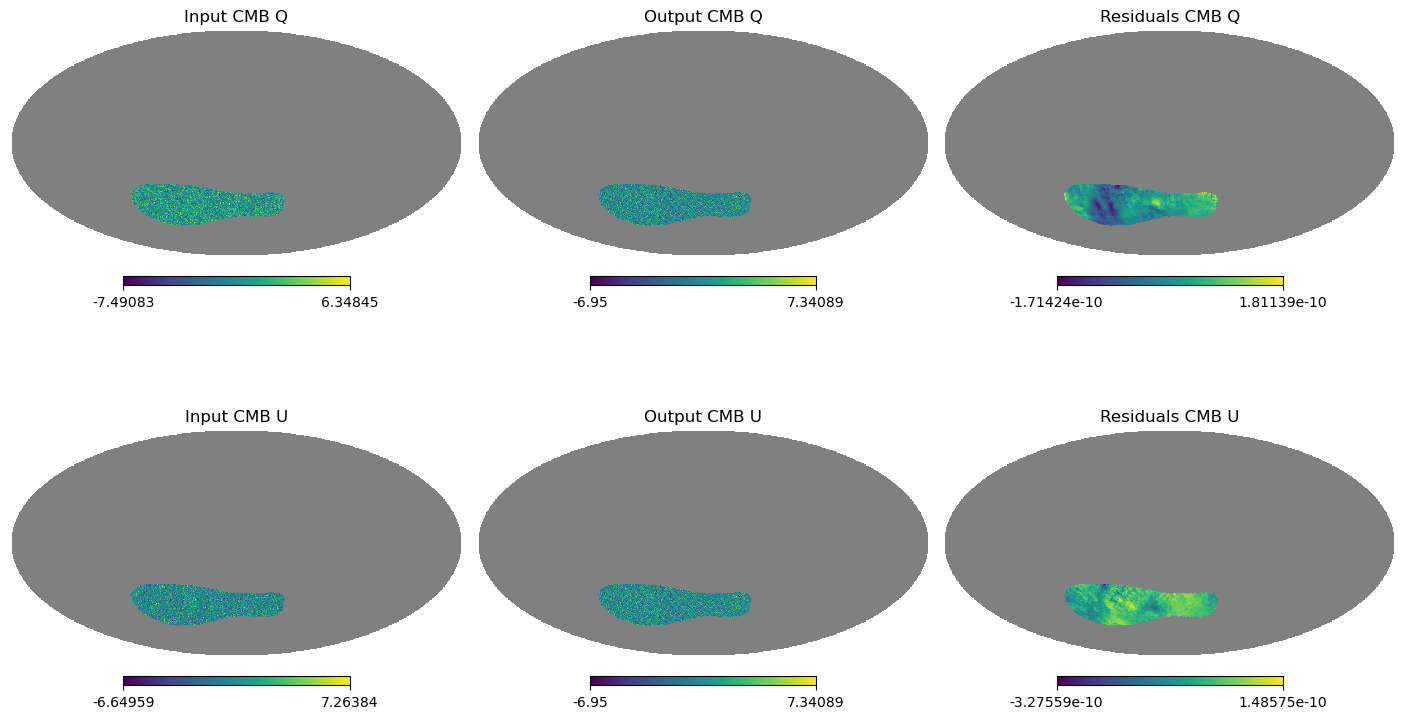

In [12]:
extended_map = np.ones((nstokes, npix))*hp.UNSEEN

plt.figure(figsize=(14,8))

ncol = 3

label_stokes = ['Q', 'U']

extended_map[:, mask_indices] = input_cmb[0,1:,mask_indices].T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol), title=f'Input CMB {label_stokes[i]}', nest=True)

#extended_map[:, mask_indices] = final_map[0,:,:]

extended_map = np.ones((nstokes, npix))*hp.UNSEEN
extended_map[:, mask_B_ring!=0] = final_map[0,i,mask_B_ring!=0]
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol + 1), title=f'Output CMB {label_stokes[i]}') #, nest=True)

extended_map = np.ones((nstokes, npix))*hp.UNSEEN
extended_map[:, mask_B_ring!=0] = (input_cmb[0,1:,mask_B_ring!=0] - final_map[0,:,mask_B_ring!=0]).T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol + 2), title=f'Residuals CMB {label_stokes[i]}') #, nest=True)


In [13]:
extended_map_input_nested = np.zeros((3, npix))
extended_map_input_nested[1:, mask_indices] = hp.reorder(input_cmb[0,1:],r2n=True)[...,mask_indices]

extended_map_output = np.zeros((3, npix))
extended_map_output[1:, mask_B_ring!=0] = final_map[0,:,mask_B_ring!=0].T

extended_map_input = hp.reorder(extended_map_input_nested, n2r=True)


In [14]:
lmax = 2*nside

In [15]:
c_ell_input = hp.anafast(extended_map_input, lmax=lmax)
c_ell_output = hp.anafast(extended_map_output, lmax=lmax)#/f_sky

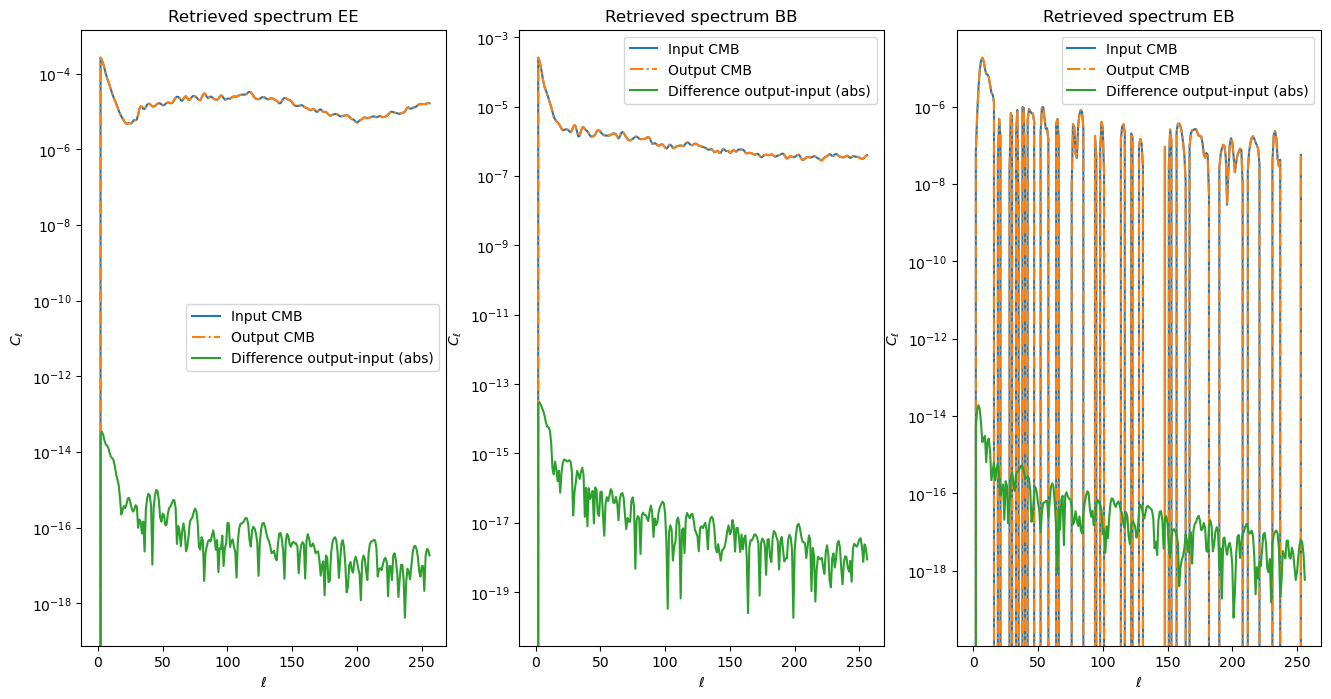

In [17]:
correl_list = ['TT', 'EE', 'BB', 'TE', 'EB', 'TB']

plt.figure(figsize=(16,8))
for k, i in enumerate([1,2,4]):
    plt.subplot(131+k)
    plt.plot(c_ell_input[i], label='Input CMB')
    plt.plot(c_ell_output[i], '-.', label='Output CMB')
    plt.plot(np.abs(c_ell_input[i]-c_ell_output[i]), label='Difference output-input (abs)')
    plt.yscale('log')
    plt.title(f"Retrieved spectrum {correl_list[i]}")
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$C_\ell$")
    plt.legend()
plt.show()